In [35]:
import pandas as pd

# === Load the CSV ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Ensure datetime and numeric age columns ===
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['repo_age_years'] = pd.to_numeric(df['repo_age_years'], errors='coerce')

# === Drop rows with missing age info ===
df = df.dropna(subset=['repo_age_years'])

# === Create Age Quartiles and add to DataFrame ===
df['age_quartile'] = pd.qcut(df['repo_age_years'], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Build Summary Table ===
summary_rows = []

for quartile in ["Q1", "Q2", "Q3", "Q4"]:
    subset = df[df['age_quartile'] == quartile]
    count = len(subset)
    start_date = subset['created_at'].min()
    end_date = subset['created_at'].max()
    
    if pd.isna(start_date) or pd.isna(end_date):
        range_str = "N/A"
        length_years = "N/A"
    else:
        range_str = f"{start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"
        length_years = round((end_date - start_date).days / 365.25, 1)

    summary_rows.append({
        'Quartile': quartile,
        'Repo Count': count,
        'Created At Range': range_str,
        'Quartile Length (Years)': length_years
    })

# === Create and Show Summary Table ===
summary_df = pd.DataFrame(summary_rows)
print(summary_df)

# === Save Summary Table ===
summary_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\Age_Quartile_Summary.csv"
summary_df.to_csv(summary_path, index=False)
print("✅ Summary saved to:", summary_path)

# === Overwrite input CSV with new column ===
df.to_csv(file_path, index=False)
print("✅ Updated input CSV saved (with age_quartile column):", file_path)


  Quartile  Repo Count          Created At Range  Quartile Length (Years)
0       Q1        1133  2022-03-06 to 2024-12-31                      2.8
1       Q2        1122  2019-11-24 to 2022-03-04                      2.3
2       Q3        1130  2016-12-26 to 2019-11-23                      2.9
3       Q4        1125  2008-10-02 to 2016-12-24                      8.2
✅ Summary saved to: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\Age_Quartile_Summary.csv
✅ Updated input CSV saved (with age_quartile column): C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv


In [36]:
import pandas as pd

# === File Paths ===
input_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
output_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\KPI_Summary_Stats.csv"

# === Load the Data ===
df = pd.read_csv(input_path)

# === Define KPI Columns (modifiable list) ===
kpi_columns = [
    'repo_age_years',
    'size',
    'stargazers_count',
    'nbr_of_manifest',
    'yml_GitHub_Actions',
    'yml_Travis_CI',          
    'commits_GitAPI'
]

# === Create Summary Table ===
summary_stats = df[kpi_columns].describe(percentiles=[0.25, 0.5, 0.75]).loc[['min', '25%', '50%', '75%', 'max']]
summary_stats.index = ['Min', 'Q1', 'Median', 'Q3', 'Max']
summary_stats = summary_stats.transpose().round(1)  # Round to 1 decimal place

# === Save to CSV ===
summary_stats.to_csv(output_path)

print(summary_stats)
print("✅ Rounded KPI summary table saved to:")
print(output_path)


                     Min      Q1   Median       Q3        Max
repo_age_years       0.5     3.4      5.6      8.5       16.8
size                36.0  2226.8  10101.0  42862.2  8996657.0
stargazers_count    50.0    98.0    217.0    639.8    99443.0
nbr_of_manifest      1.0     1.0      2.0      3.0      122.0
yml_GitHub_Actions   0.0     0.0      1.0      2.0      149.0
yml_Travis_CI        0.0     0.0      0.0      1.0        1.0
commits_GitAPI       1.0    81.0    259.0    865.0   120828.0
✅ Rounded KPI summary table saved to:
C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\KPI_Summary_Stats.csv


📊 Distribution of instr_test_ci=True among Age Quartiles (out of total instr_test_ci repos):

              With instr_test_ci  Share of Total (%)
age_quartile                                        
Q1                            71               18.98
Q2                            94               25.13
Q3                            78               20.86
Q4                           131               35.03


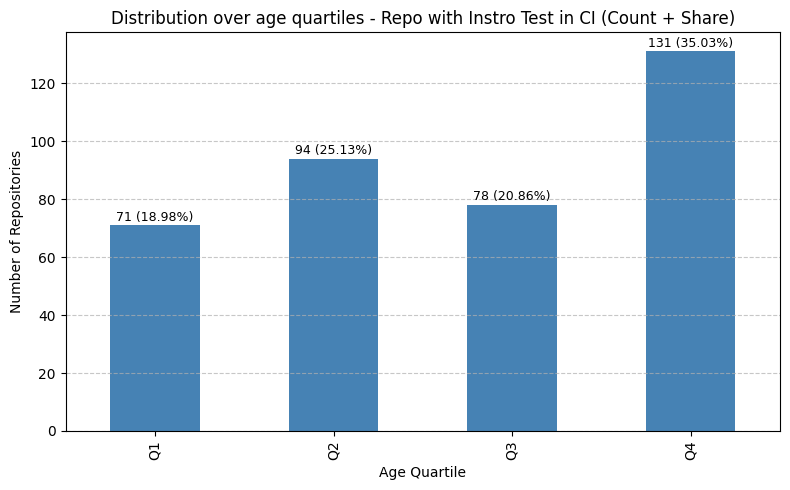

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD FILE ===
df = pd.read_csv(file_path)

# === Convert instr_test_ci to boolean ===
df['instr_test_ci'] = df['instr_test_ci'].astype(str).str.lower().str.strip() == "true"

# === Ensure age_quartile column exists and is valid ===
if 'age_quartile' not in df.columns:
    raise ValueError("❌ 'age_quartile' column is missing. Please run age quartile assignment first.")

df = df.dropna(subset=['age_quartile'])

# === Filter repos with instr_test_ci == True ===
df_true = df[df['instr_test_ci']]

# === Total number with instr_test_ci == True ===
total_true = len(df_true)

# === Count per quartile among instr_test_ci == True ===
ci_true_counts = df_true['age_quartile'].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0).astype(int)

# === Calculate share (%) out of total instr_test_ci==True ===
ci_true_percent = (ci_true_counts / total_true * 100).round(2)

# === Print Distribution Table ===
distribution_df = pd.DataFrame({
    "With instr_test_ci": ci_true_counts,
    "Share of Total (%)": ci_true_percent
})
print("📊 Distribution of instr_test_ci=True among Age Quartiles (out of total instr_test_ci repos):\n")
print(distribution_df)

# === Plot ===
fig, ax = plt.subplots(figsize=(8, 5))
ci_true_counts.plot(kind='bar', color='steelblue', ax=ax)

ax.set_title("Distribution over age quartiles - Repo with Instro Test in CI (Count + Share)")
ax.set_xlabel("Age Quartile")
ax.set_ylabel("Number of Repositories")
ax.grid(axis='y', linestyle='--', alpha=0.7)

# === Add count + % labels above bars ===
for i, quartile in enumerate(ci_true_counts.index):
    count = ci_true_counts[quartile]
    percent = ci_true_percent[quartile]
    label = f"{count} ({percent}%)"
    ax.text(i, count + 0.5, label, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


📊 Distribution of instr_test_build==True among Age Quartiles (out of total instr_test_ci repos):

              With instr_test_ci  Share of Total (%)
age_quartile                                        
Q1                           316               23.20
Q2                           375               27.53
Q3                           438               32.16
Q4                           233               17.11


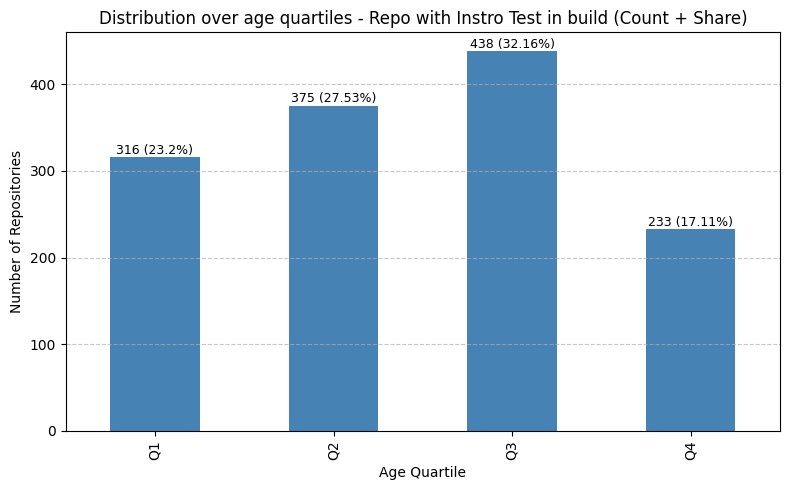

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD FILE ===
df = pd.read_csv(file_path)

# === Convert instr_test_ci to boolean ===
df['instr_test_build'] = df['instr_test_build'].astype(str).str.lower().str.strip() == "true"

# === Ensure age_quartile column exists and is valid ===
if 'age_quartile' not in df.columns:
    raise ValueError("❌ 'age_quartile' column is missing. Please run age quartile assignment first.")

df = df.dropna(subset=['age_quartile'])

# === Filter repos with instr_test_ci == True ===
df_true = df[df['instr_test_build']]

# === Total number with instr_test_ci == True ===
total_true = len(df_true)

# === Count per quartile among instr_test_ci == True ===
ci_true_counts = df_true['age_quartile'].value_counts().reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0).astype(int)

# === Calculate share (%) out of total instr_test_ci==True ===
ci_true_percent = (ci_true_counts / total_true * 100).round(2)

# === Print Distribution Table ===
distribution_df = pd.DataFrame({
    "With instr_test_ci": ci_true_counts,
    "Share of Total (%)": ci_true_percent
})
print("📊 Distribution of instr_test_build==True among Age Quartiles (out of total instr_test_ci repos):\n")
print(distribution_df)

# === Plot ===
fig, ax = plt.subplots(figsize=(8, 5))
ci_true_counts.plot(kind='bar', color='steelblue', ax=ax)

ax.set_title("Distribution over age quartiles - Repo with Instro Test in build (Count + Share)")
ax.set_xlabel("Age Quartile")
ax.set_ylabel("Number of Repositories")
ax.grid(axis='y', linestyle='--', alpha=0.7)

# === Add count + % labels above bars ===
for i, quartile in enumerate(ci_true_counts.index):
    count = ci_true_counts[quartile]
    percent = ci_true_percent[quartile]
    label = f"{count} ({percent}%)"
    ax.text(i, count + 0.5, label, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Grouping the repos to these tiers: 

    Tier 1 – Instrumentation in Build and YML
    Tier 2 – Instrumentation in YML Only
    Tier 3 – Instrumentation in Build Only
    Tier 4 – No Instrumentation
Saves the Tier of each Repo in the main spreadsheet

✅ Saved updated CSV with Tier: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv
✅ Tier counts:
 Tier
Tier 1\nInstru Test in Build and YML     171
Tier 2\nInstru Test in YML Only          203
Tier 3\nInstru Test in Build Only       1191
Tier 4\nNo Instru Test                  2945
Name: count, dtype: int64
✅ Tier rates (%):
 Tier
Tier 1\nInstru Test in Build and YML     3.8
Tier 2\nInstru Test in YML Only          4.5
Tier 3\nInstru Test in Build Only       26.4
Tier 4\nNo Instru Test                  65.3
Name: count, dtype: float64


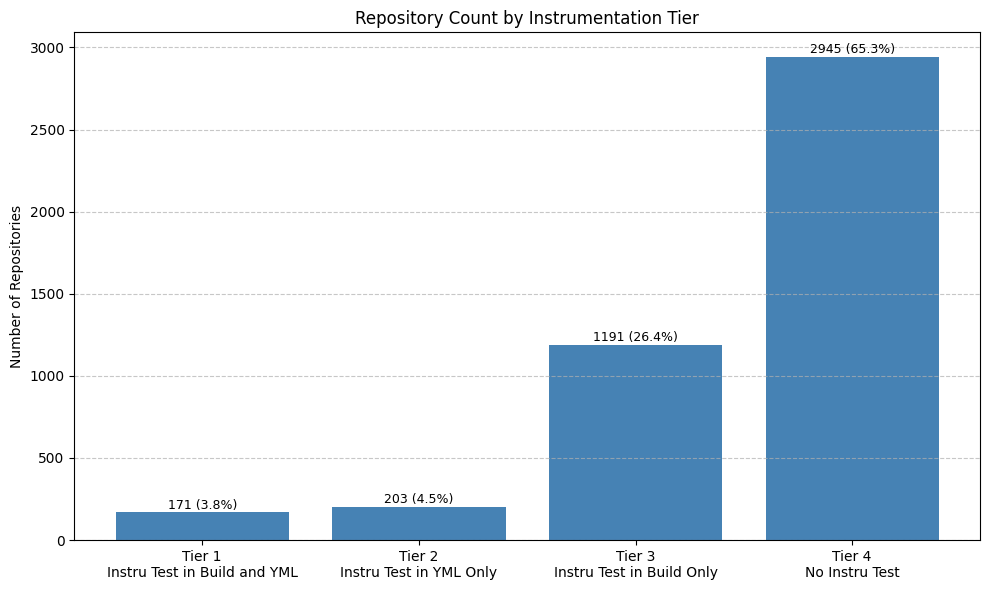

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in ["instr_test_build", "instr_test_ci"]:
    df[col] = df[col].astype(str).str.lower() == "true"

# === Drop rows with missing instrumentation info ===
df = df.dropna(subset=["instr_test_build", "instr_test_ci"])

# === Apply Updated Tier Logic ===
def assign_tier(row):
    if row["instr_test_build"] and row["instr_test_ci"]:
        return "Tier 1\nInstru Test in Build and YML"
    elif row["instr_test_ci"] and not row["instr_test_build"]:
        return "Tier 2\nInstru Test in YML Only"
    elif row["instr_test_build"] and not row["instr_test_ci"]:
        return "Tier 3\nInstru Test in Build Only"
    else:
        return "Tier 4\nNo Instru Test"

df["Tier"] = df.apply(assign_tier, axis=1)

# === Save updated CSV ===
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with Tier: {file_path}")

# === Compute counts and rates ===
tier_counts = df["Tier"].value_counts().sort_index()
tier_rates = (tier_counts / tier_counts.sum() * 100).round(1)

print("✅ Tier counts:\n", tier_counts)
print("✅ Tier rates (%):\n", tier_rates)

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(tier_counts.index, tier_counts.values, color='steelblue')

# Annotate bars
for bar, count, rate in zip(bars, tier_counts.values, tier_rates.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
            f"{count} ({rate:.1f}%)", ha='center', va='bottom', fontsize=9)

ax.set_ylabel("Number of Repositories")
ax.set_title("Repository Count by Instrumentation Tier")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Grouping the repos to these tiers: 

    Tier 1 – CI-Tested Instrumentation
    Tier 2 – buildly-Tested Instrumentation
    Tier 3 – Unite-Tested Only
    Tier 4 – Untested
Saves the Tier of each Repo in the main spreadsheet



✅ Saved updated CSV with Tier: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv
✅ Tier counts:
 Tier
Tier 1 - CI-Tested Instrumentation        374
Tier 2 - build-Tested Instrumentation    1191
Tier 3 - Unit Tests Only                 1099
Tier 4 - Untested                        1846
Name: count, dtype: int64
✅ Tier rates (%):
 Tier
Tier 1 - CI-Tested Instrumentation        8.3
Tier 2 - build-Tested Instrumentation    26.4
Tier 3 - Unit Tests Only                 24.4
Tier 4 - Untested                        40.9
Name: count, dtype: float64


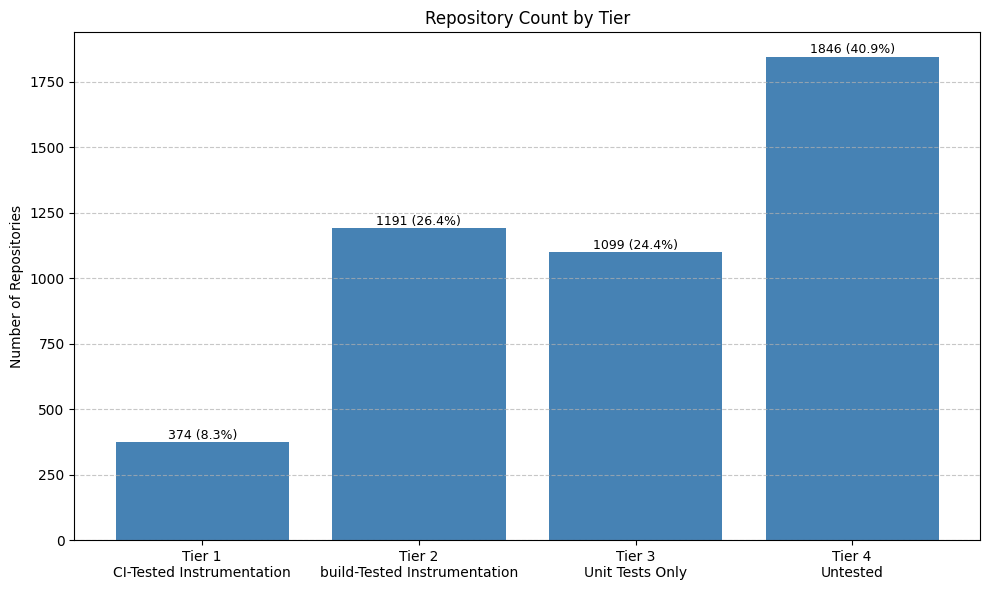

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_build", "unit_test_ci",
    "instr_test_build", "instr_test_ci",
    "Unit_Test(CI or build)", "Instr_Test(CI or build)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Drop rows with missing critical info (optional: based on created_at or tests) ===
# Here, assume no created_at check needed for Tiers; focus on test flags only.
df = df.dropna(subset=[
    "unit_test_build", "unit_test_ci",
    "instr_test_build", "instr_test_ci"
])

# === Define Tier logic ===
def assign_tier(row):
    if row["instr_test_ci"]:
        return "Tier 1 - CI-Tested Instrumentation"
    elif row["instr_test_build"] and not row["instr_test_ci"]:
        return "Tier 2 - build-Tested Instrumentation"
    elif ((row["unit_test_build"] or row["unit_test_ci"]) and not (row["instr_test_build"] or row["instr_test_ci"])):
        return "Tier 3 - Unit Tests Only"
    else:
        return "Tier 4 - Untested"

df["Tier"] = df.apply(assign_tier, axis=1)

# === Reorder columns to place Tier at end ===
cols = [col for col in df.columns if col != "Tier"] + ["Tier"]
df = df[cols]

# === Save updated CSV ===
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with Tier: {file_path}")

# === Compute counts and rates ===
tier_counts = df["Tier"].value_counts().sort_index()
tier_rates = (tier_counts / tier_counts.sum() * 100).round(1)
print("✅ Tier counts:\n", tier_counts)
print("✅ Tier rates (%):\n", tier_rates)

# === Plot ===
# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

# ✅ Wrap labels by splitting at " - "
wrapped_labels = [label.replace(" - ", "\n") for label in tier_counts.index]

# Plot using wrapped labels
bars = ax.bar(wrapped_labels, tier_counts.values, color='steelblue')

# Add labels: count + rate
for bar, count, rate in zip(bars, tier_counts.values, tier_rates.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2,
            f"{count} ({rate:.1f}%)",
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel("Number of Repositories")
ax.set_title("Repository Count by Tier")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


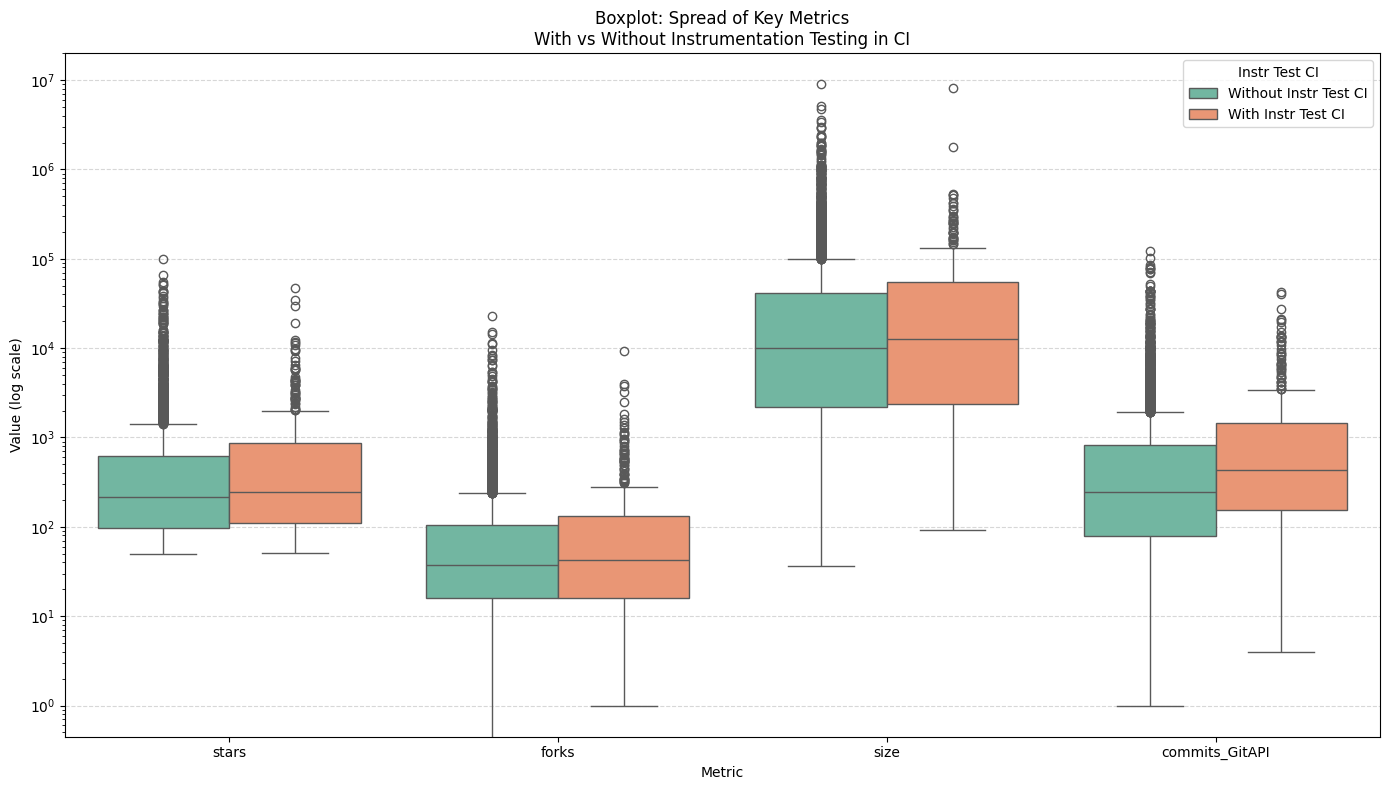

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === LOAD ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Prepare columns ===
df["instr_test_ci"] = df["instr_test_ci"].astype(str).str.lower() == "true"
df["stars"] = pd.to_numeric(df["stargazers_count"], errors="coerce")
df["forks"] = pd.to_numeric(df["forks_count"], errors="coerce")

df["size"] = pd.to_numeric(df["size"], errors="coerce")
df["commits_GitAPI"] = pd.to_numeric(df["commits_GitAPI"], errors="coerce")

# === Melt for seaborn ===
metrics = ["stars", "forks", "size", "commits_GitAPI"]
df_box = df[["instr_test_ci"] + metrics].copy()
df_box["instr_test_ci"] = df_box["instr_test_ci"].map({True: "With Instr Test CI", False: "Without Instr Test CI"})
df_melted = df_box.melt(id_vars="instr_test_ci", var_name="Metric", value_name="Value")

# === Boxplot ===
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x="Metric", y="Value", hue="instr_test_ci", palette="Set2")
plt.title("Boxplot: Spread of Key Metrics\nWith vs Without Instrumentation Testing in CI")
plt.ylabel("Value (log scale)")
plt.xlabel("Metric")
plt.yscale("log")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Instr Test CI")
plt.tight_layout()
plt.show()


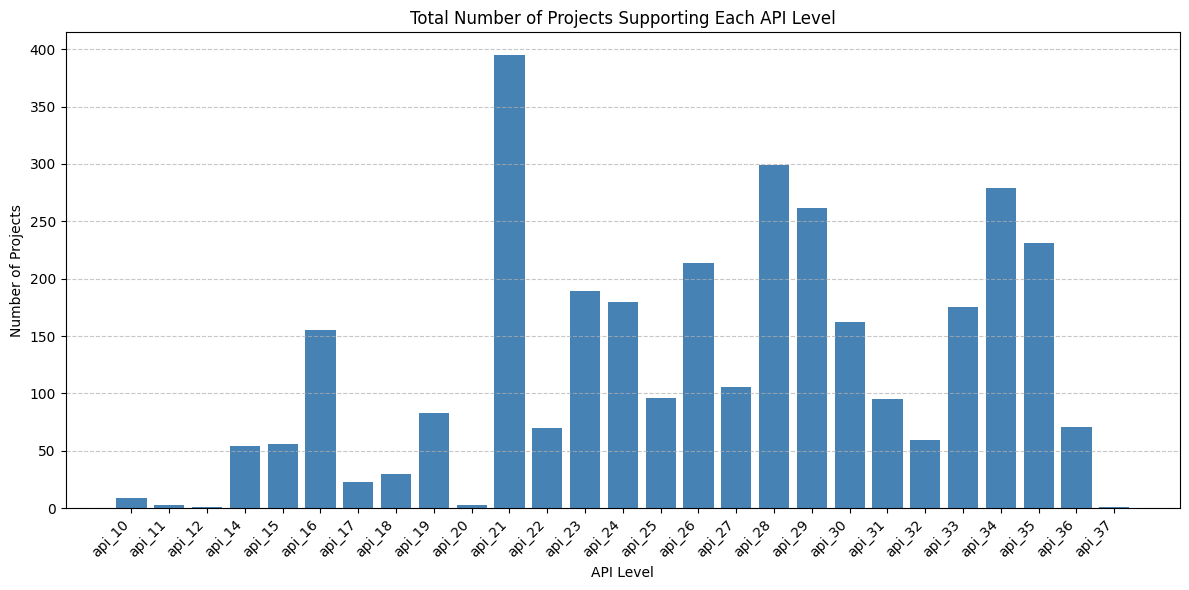

In [43]:
# API_Levels Plotting All available API levels
# This script reads a CSV file containing API level data and plots the total number of API_levels
import pandas as pd
import matplotlib.pyplot as plt

# === Load the CSV ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Select API level columns (exclude 'api_level_count') ===
api_columns = [col for col in df.columns if col.startswith("api_") and col != "api_level_count"]

# === Sum values across all rows for each API column ===
api_sums = df[api_columns].sum().sort_index()

# === Plotting ===
plt.figure(figsize=(12, 6))
bars = plt.bar(api_sums.index, api_sums.values, color='steelblue')
plt.xlabel("API Level")
plt.ylabel("Number of Projects")
plt.title("Total Number of Projects Supporting Each API Level")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


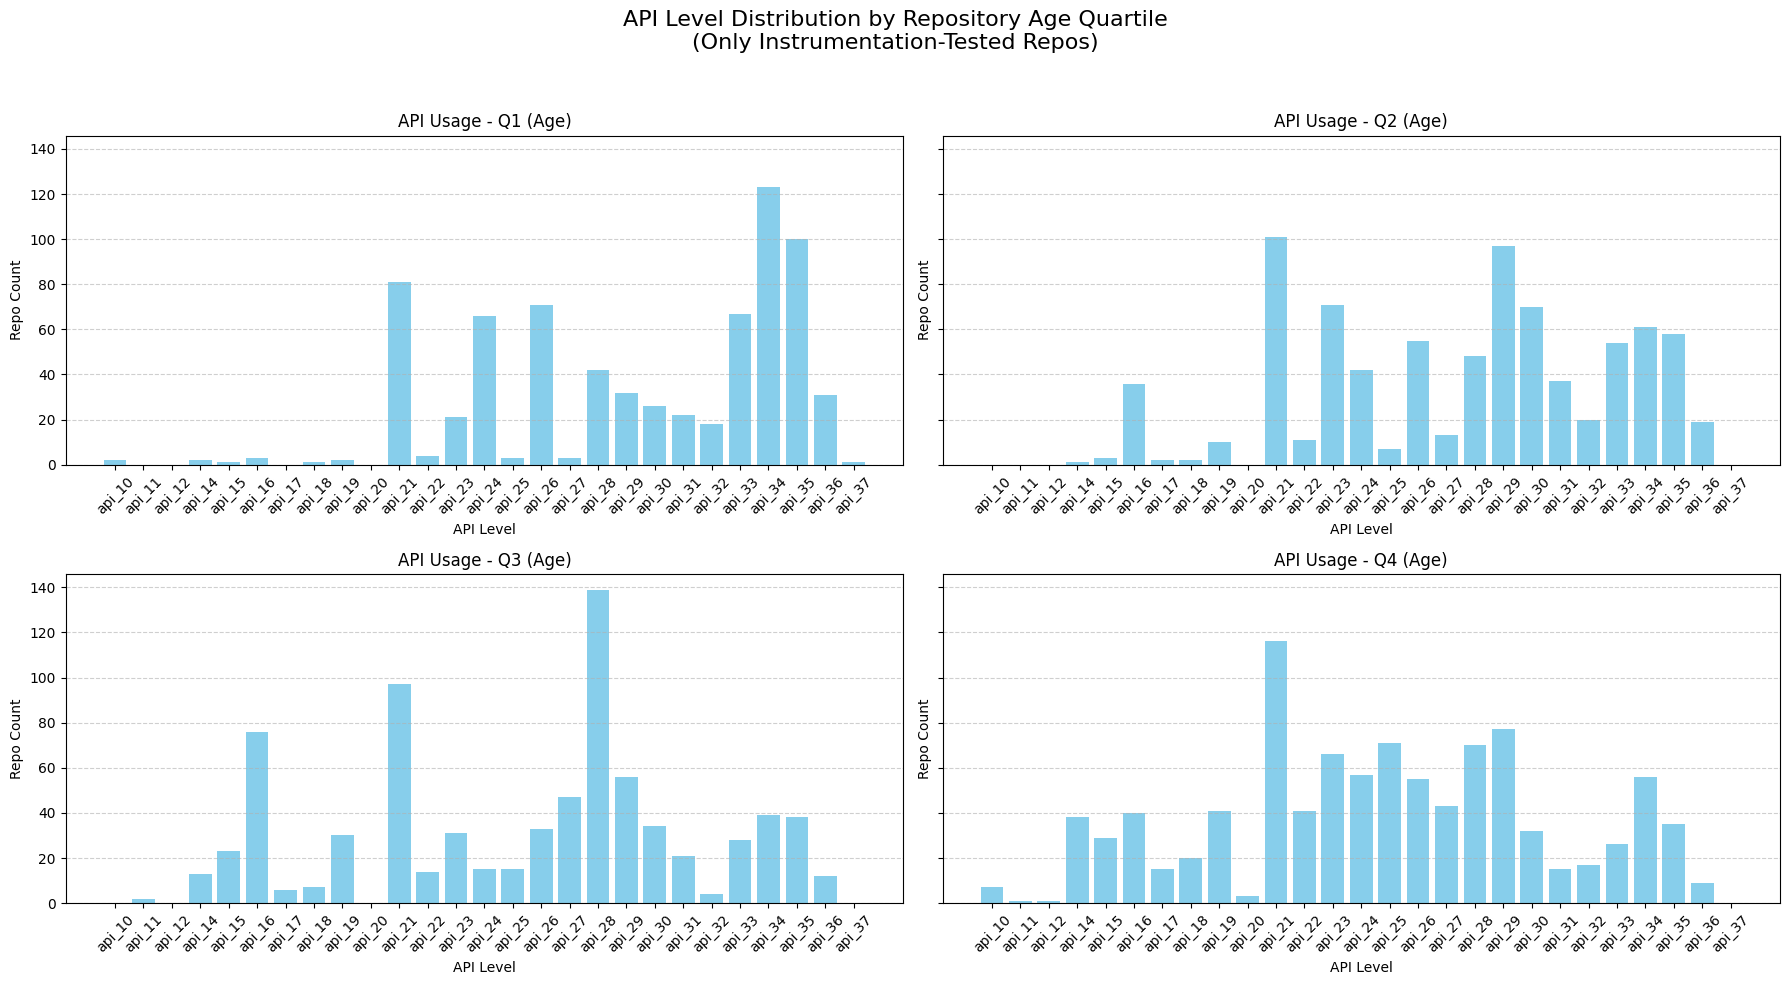

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load Data ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Ensure proper boolean conversion for filtering ===
df['Instr_Test(CI or build)'] = df['Instr_Test(CI or build)'].astype(str).str.lower() == 'true'

# === Filter for Instrumentation-Tested Repos ===
df = df[df['Instr_Test(CI or build)'] == True]

# === Select API level columns (exclude 'api_level_count') ===
api_columns = [col for col in df.columns if col.startswith("api_") and col != "api_level_count"]

# === Create Age Quartiles ===
df['age_quartile'] = pd.qcut(df['repo_age_years'], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Setup Plot ===
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.flatten()

# === Plot for Each Quartile ===
for i, quartile in enumerate(["Q1", "Q2", "Q3", "Q4"]):
    ax = axes[i]
    subset = df[df['age_quartile'] == quartile]
    api_sums = subset[api_columns].sum().sort_index()

    ax.bar(api_sums.index, api_sums.values, color='skyblue')
    ax.set_title(f"API Usage - {quartile} (Age)")
    ax.set_xlabel("API Level")
    ax.set_ylabel("Repo Count")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# === Final Layout ===
plt.suptitle("API Level Distribution by Repository Age Quartile\n(Only Instrumentation-Tested Repos)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


📊 Language Frequency:
            Language  Count
0             Kotlin   1522
1               Java   1361
2               Dart    747
3                C++    238
4         TypeScript    187
5         JavaScript    129
6                  C     99
7               Rust     38
8             Python     24
9        Objective-C     22
10              HTML     19
11             Swift     17
12                Go     16
13                C#     15
14               Vue     12
15             Scala      7
16  Jupyter Notebook      6
17     Objective-C++      6
18               NaN      6
19            Svelte      5
20               Lua      4
21            Groovy      3
22               QML      3
23             Shell      3
24               CSS      2
25                 D      2
26               Nim      2
27                 V      2
28           Clojure      2
29               PHP      1
30            Scheme      1
31               Red      1
32               Nix      1
33              Vala      

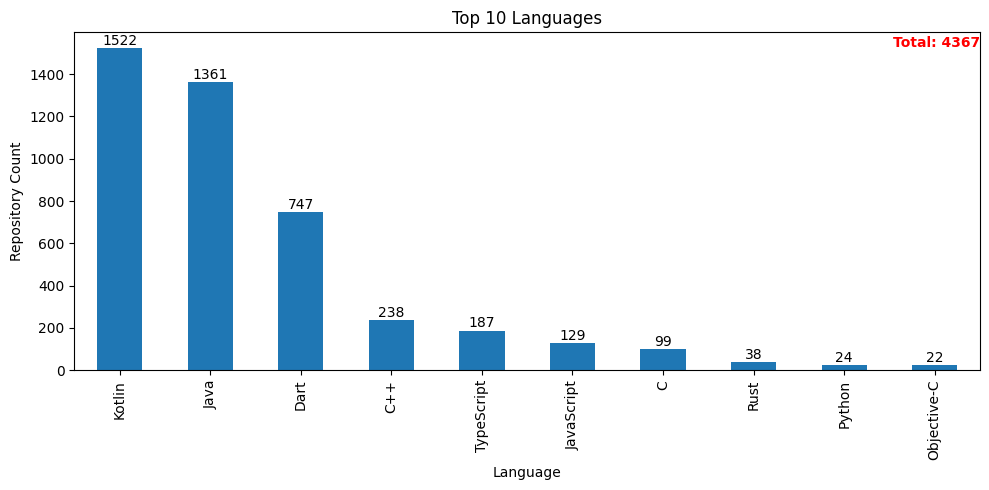

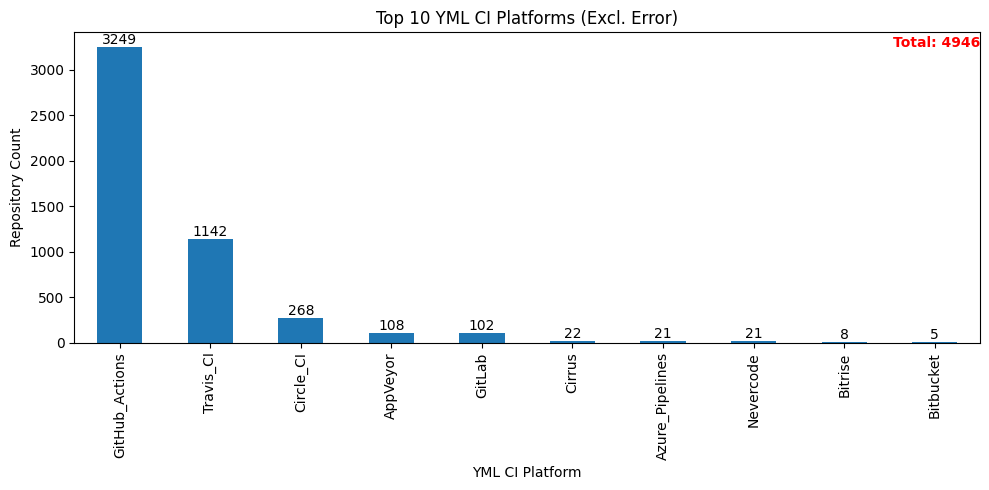

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === LANGUAGE FREQUENCY ===
language_counts = df['language'].value_counts(dropna=False).reset_index()
language_counts.columns = ['Language', 'Count']
language_top10 = language_counts.head(10)
language_total = language_top10['Count'].sum()

# === YML CI PLATFORM FREQUENCY (excluding 'Error') ===
ci_yml = df['ci_platform_yml'].dropna().str.split(',', expand=True).stack().str.strip()
ci_yml = ci_yml[ci_yml.str.lower() != 'error']  # Remove 'Error'
ci_yml_counts = ci_yml.value_counts().reset_index()
ci_yml_counts.columns = ['YML CI Platform', 'Count']
ci_top10 = ci_yml_counts.head(10)
ci_total = ci_top10['Count'].sum()

# === DISPLAY TABLES ===
print("📊 Language Frequency:")
print(language_counts)
print("\n📊 YML CI Platform Frequency (excluding 'Error'):")
print(ci_yml_counts)

# === PLOT 1: LANGUAGE FREQUENCY ===
plt.figure(figsize=(10, 5))
ax1 = plt.gca()
language_top10.plot(kind='bar', x='Language', y='Count', legend=False, ax=ax1, title='Top 10 Languages')
plt.ylabel("Repository Count")
for i, v in enumerate(language_top10['Count']):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom')

# Add total count at the end
ax1.text(len(language_top10) - 0.5, language_top10['Count'].max() + 5, f"Total: {language_total}", fontsize=10, color='red', fontweight='bold', ha='right')
plt.tight_layout()
plt.show()

# === PLOT 2: YML CI PLATFORM FREQUENCY ===
plt.figure(figsize=(10, 5))
ax2 = plt.gca()
ci_top10.plot(kind='bar', x='YML CI Platform', y='Count', legend=False, ax=ax2, title='Top 10 YML CI Platforms (Excl. Error)')
plt.ylabel("Repository Count")
for i, v in enumerate(ci_top10['Count']):
    ax2.text(i, v + 1, str(v), ha='center', va='bottom')

# Add total count at the end
ax2.text(len(ci_top10) - 0.5, ci_top10['Count'].max() + 5, f"Total: {ci_total}", fontsize=10, color='red', fontweight='bold', ha='right')
plt.tight_layout()
plt.show()


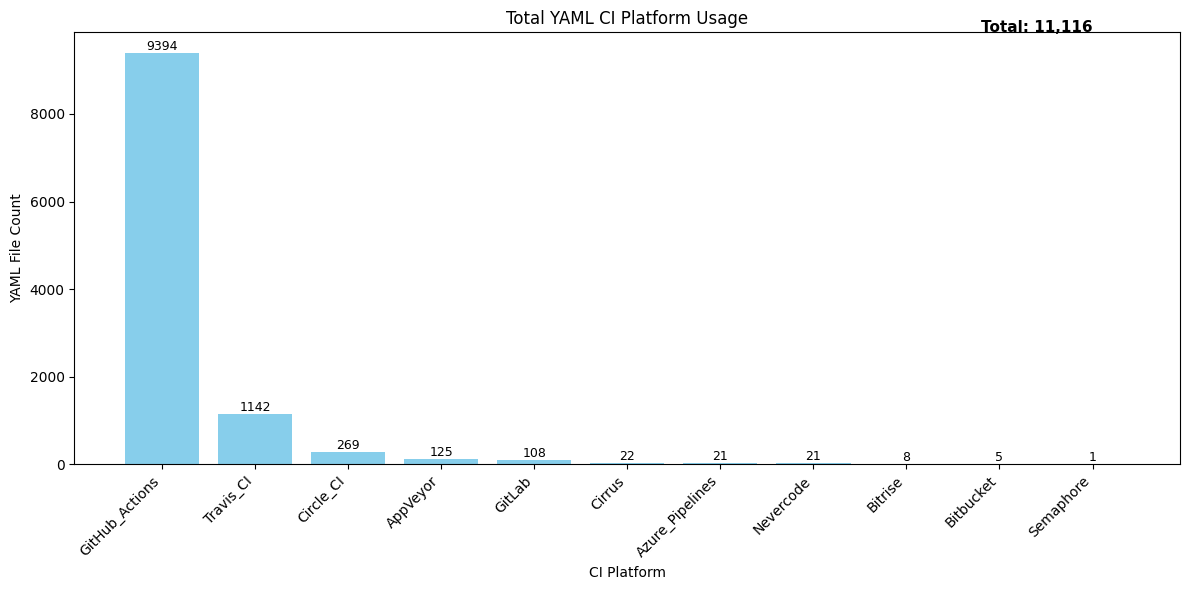

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === SELECT YML COLUMNS (EXCLUDE 'yml_Error') ===
yml_columns = [col for col in df.columns if col.startswith('yml_') and col.lower() != 'yml_error']

# === CONVERT YML COLUMNS TO NUMERIC (IN CASE OF ANY NON-NUMERIC VALUES) ===
df[yml_columns] = df[yml_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# === CALCULATE TOTAL COUNTS FOR EACH CI PLATFORM ===
ci_totals = df[yml_columns].sum().sort_values(ascending=False)
ci_totals = ci_totals[ci_totals > 0]

# === PLOT ===
plt.figure(figsize=(12, 6))
bars = plt.bar(ci_totals.index.str.replace('yml_', ''), ci_totals.values, color='skyblue')
plt.title('Total YAML CI Platform Usage')
plt.xlabel('CI Platform')
plt.ylabel('YAML File Count')

# === ADD LABELS TO EACH BAR ===
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

# === ADD GRAND TOTAL LABEL ===
total_count = int(ci_totals.sum())
plt.text(len(ci_totals)-1, max(ci_totals)*1.05, f'Total: {total_count:,}', ha='right', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


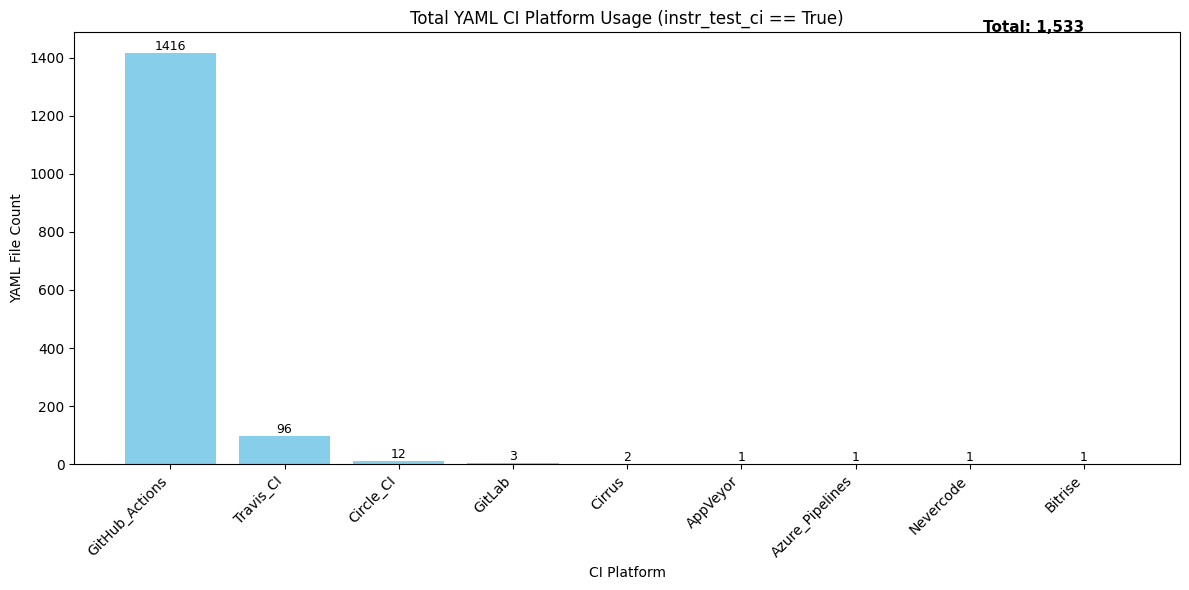

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# === FILE PATH ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"

# === LOAD DATA ===
df = pd.read_csv(file_path)

# === FILTER: Only instr_test_ci == True ===
df = df[df['instr_test_ci'] == True]

# === SELECT YML COLUMNS (EXCLUDE 'yml_Error') ===
yml_columns = [col for col in df.columns if col.startswith('yml_') and col.lower() != 'yml_error']

# === CONVERT YML COLUMNS TO NUMERIC (IN CASE OF ANY NON-NUMERIC VALUES) ===
df[yml_columns] = df[yml_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

# === CALCULATE TOTAL COUNTS FOR EACH CI PLATFORM ===
ci_totals = df[yml_columns].sum().sort_values(ascending=False)
ci_totals = ci_totals[ci_totals > 0]

# === PLOT ===
plt.figure(figsize=(12, 6))
bars = plt.bar(ci_totals.index.str.replace('yml_', ''), ci_totals.values, color='skyblue')
plt.title('Total YAML CI Platform Usage (instr_test_ci == True)')
plt.xlabel('CI Platform')
plt.ylabel('YAML File Count')

# === ADD LABELS TO EACH BAR ===
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

# === ADD GRAND TOTAL LABEL ===
total_count = int(ci_totals.sum())
plt.text(len(ci_totals)-1, max(ci_totals)*1.05, f'Total: {total_count:,}', ha='right', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


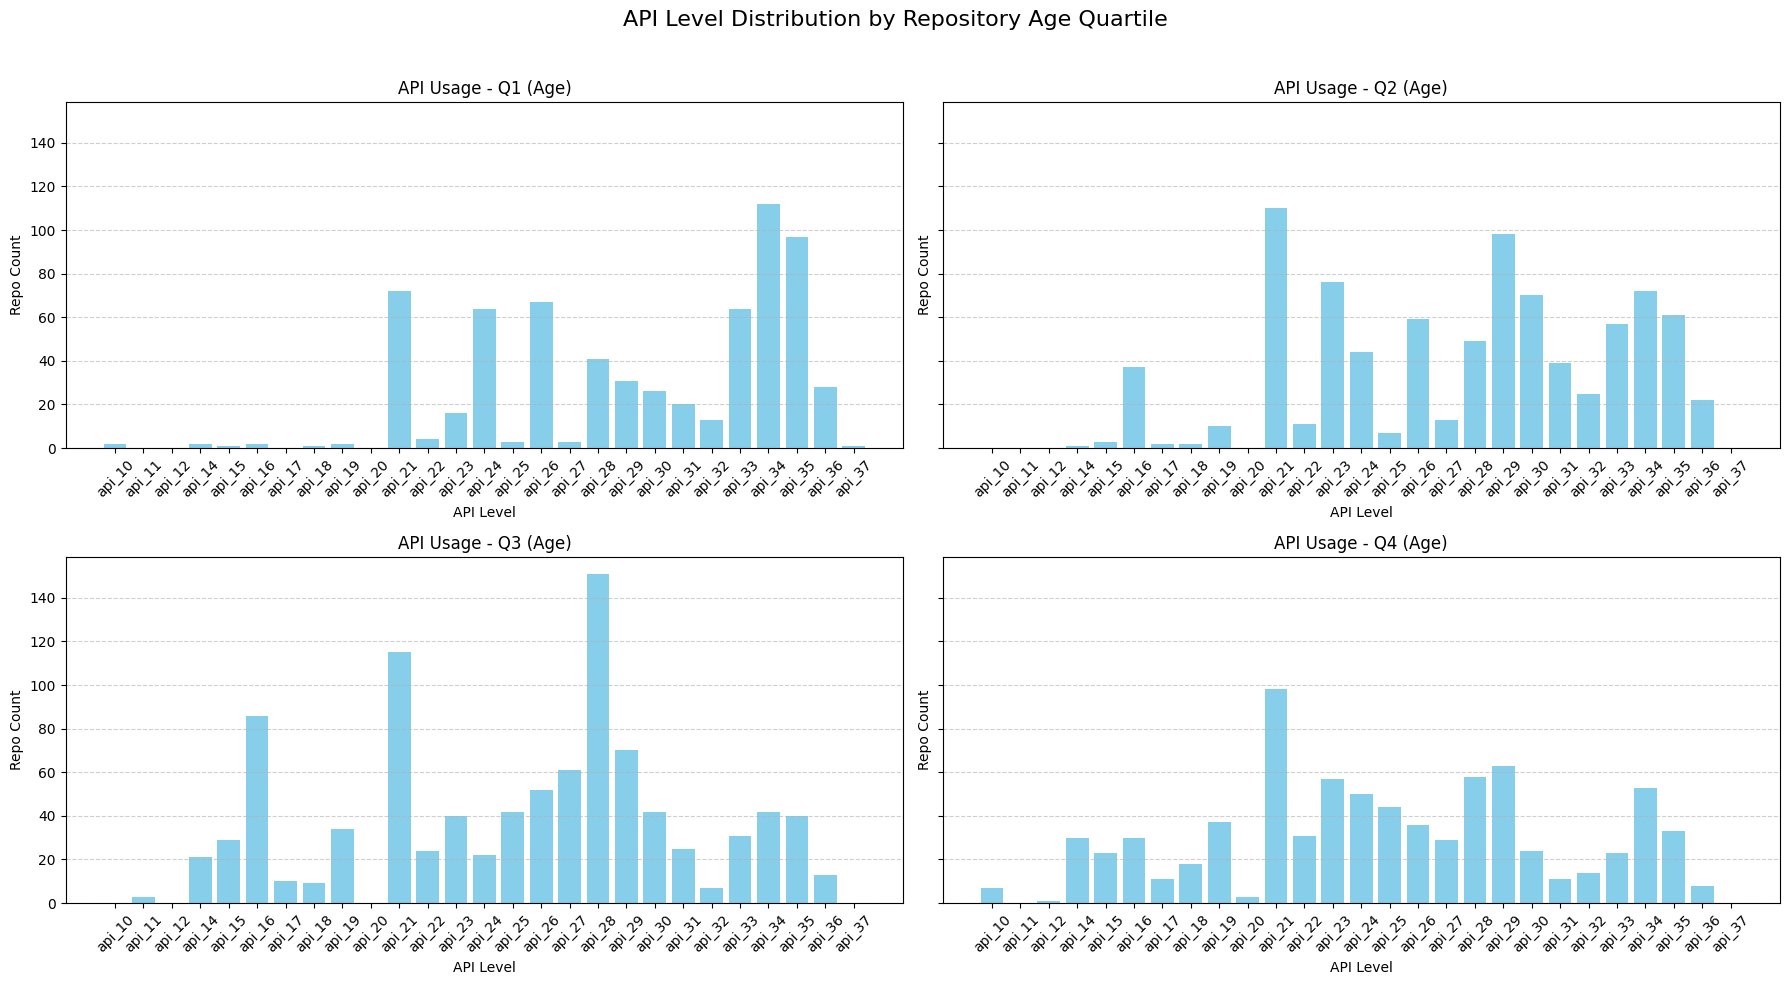

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load Data ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Select API columns (exclude 'api_level_count') ===
api_columns = [col for col in df.columns if col.startswith("api_") and col != "api_level_count"]

# === Create Age Quartiles ===
df['age_quartile'] = pd.qcut(df['repo_age_years'], 4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Setup Plot ===
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=True)
axes = axes.flatten()

# === Plot each Quartile ===
for i, quartile in enumerate(["Q1", "Q2", "Q3", "Q4"]):
    ax = axes[i]
    subset = df[df['age_quartile'] == quartile]
    api_sums = subset[api_columns].sum().sort_index()

    ax.bar(api_sums.index, api_sums.values, color='skyblue')
    ax.set_title(f"API Usage - {quartile} (Age)")
    ax.set_xlabel("API Level")
    ax.set_ylabel("Repo Count")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# === Final Layout ===
plt.suptitle("API Level Distribution by Repository Age Quartile", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [51]:
import pandas as pd

# === Load your dataset ===
file_path = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\July_31\Descriptive_Stat\3.4_Total_Repos_With_Metadata.csv"
df = pd.read_csv(file_path)

# === Exclude non-numeric or irrelevant columns ===
exclude_cols = [
    'index', 'github_url', 'full_name', 'clone_status', 'language',
    'Android_keyword', 'Standard_Manifest', 'created_at', 'updated_at',
    'pushed_at', 'ci_platform_yml', 'test_type', 'matched_keywords',
    'Unit_Test(CI or build)', 'Instr_Test(CI or build)'
]

# Filter numeric columns and exclude API dummies and metadata
numeric_df = df.select_dtypes(include=['float64', 'int64'])
important_cols = [col for col in numeric_df.columns if col not in df.columns[df.columns.str.startswith('api_')]]
important_cols = [col for col in important_cols if col not in exclude_cols]

# === Calculate five-number summary ===
summary = numeric_df[important_cols].describe(percentiles=[0.25, 0.5, 0.75]).loc[['min', '25%', '50%', '75%', 'max']]
summary.rename(index={'25%': 'Q1', '50%': 'Median', '75%': 'Q3'}, inplace=True)

# === Output summary ===
summary = summary.T  # transpose for readability
print("📊 Five-Number Summary for Key Repository Metrics:\n")
print(summary)

# === Optional: Save to CSV ===
summary.to_csv("Five_Number_Summary.csv")


📊 Five-Number Summary for Key Repository Metrics:

                       min       Q1     Median        Q3         max
nbr_of_manifest       1.00     1.00      2.000      3.00      122.00
repo_age_years        0.53     3.35      5.635      8.54       16.78
size                 36.00  2226.75  10101.000  42862.25  8996657.00
stargazers_count     50.00    98.00    217.000    639.75    99443.00
forks_count           0.00    16.00     37.000    106.00    22894.00
contributors          0.00     2.00      5.000     16.00      461.00
pull_requests         0.00     5.00     26.000    124.00    50245.00
commits_GitAPI        1.00    81.00    259.000    865.00   120828.00
NBR_YAML              1.00     1.00      1.000      2.00      149.00
yml_AppVeyor          0.00     0.00      0.000      0.00        2.00
yml_Azure_Pipelines   0.00     0.00      0.000      0.00        1.00
yml_Bitbucket         0.00     0.00      0.000      0.00        1.00
yml_Bitrise           0.00     0.00      0.000      